## 1 · Setup & Imports

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (accuracy_score, classification_report,
                                      confusion_matrix, roc_auc_score, roc_curve)
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVC

import os
os.makedirs('plots', exist_ok=True)


## 2 · Load Data

In [2]:
train = pd.read_csv('loan_sanction_train.csv')
test  = pd.read_csv('loan_sanction_test.csv')
test_ids  = test['Loan_ID'].copy()

print(f"Train: {train.shape}  |  Test: {test.shape}")
train.head()


Train: (614, 13)  |  Test: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3 · Exploratory Data Analysis

### 3.1 Missing Values

In [3]:
train.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### 3.2 Target Distribution

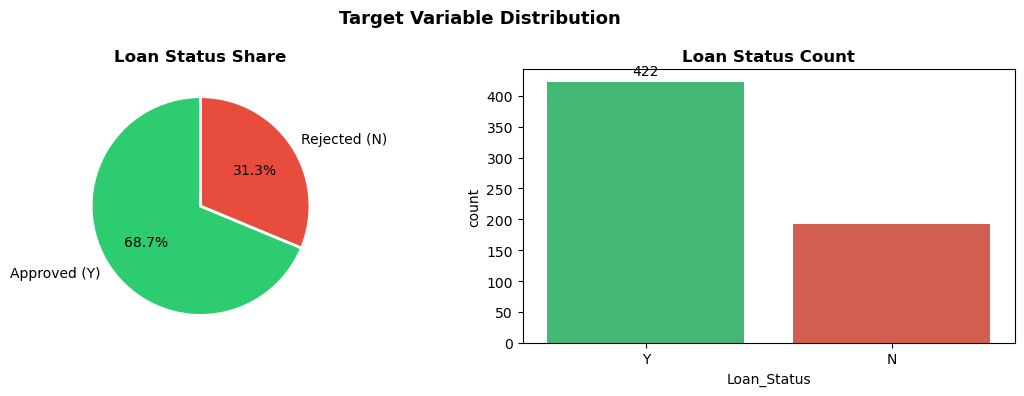

Approval rate: 68.7%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = train['Loan_Status'].value_counts()

axes[0].pie(counts, labels=['Approved (Y)', 'Rejected (N)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Loan Status Share', fontweight='bold')

sns.countplot(x='Loan_Status', data=train, palette=['#2ecc71','#e74c3c'],
              ax=axes[1], order=['Y','N'])
axes[1].set_title('Loan Status Count', fontweight='bold')
axes[1].bar_label(axes[1].containers[0], padding=3)

fig.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Approval rate: {counts['Y']/len(train)*100:.1f}%")


### 3.3 Categorical Features vs Loan Status

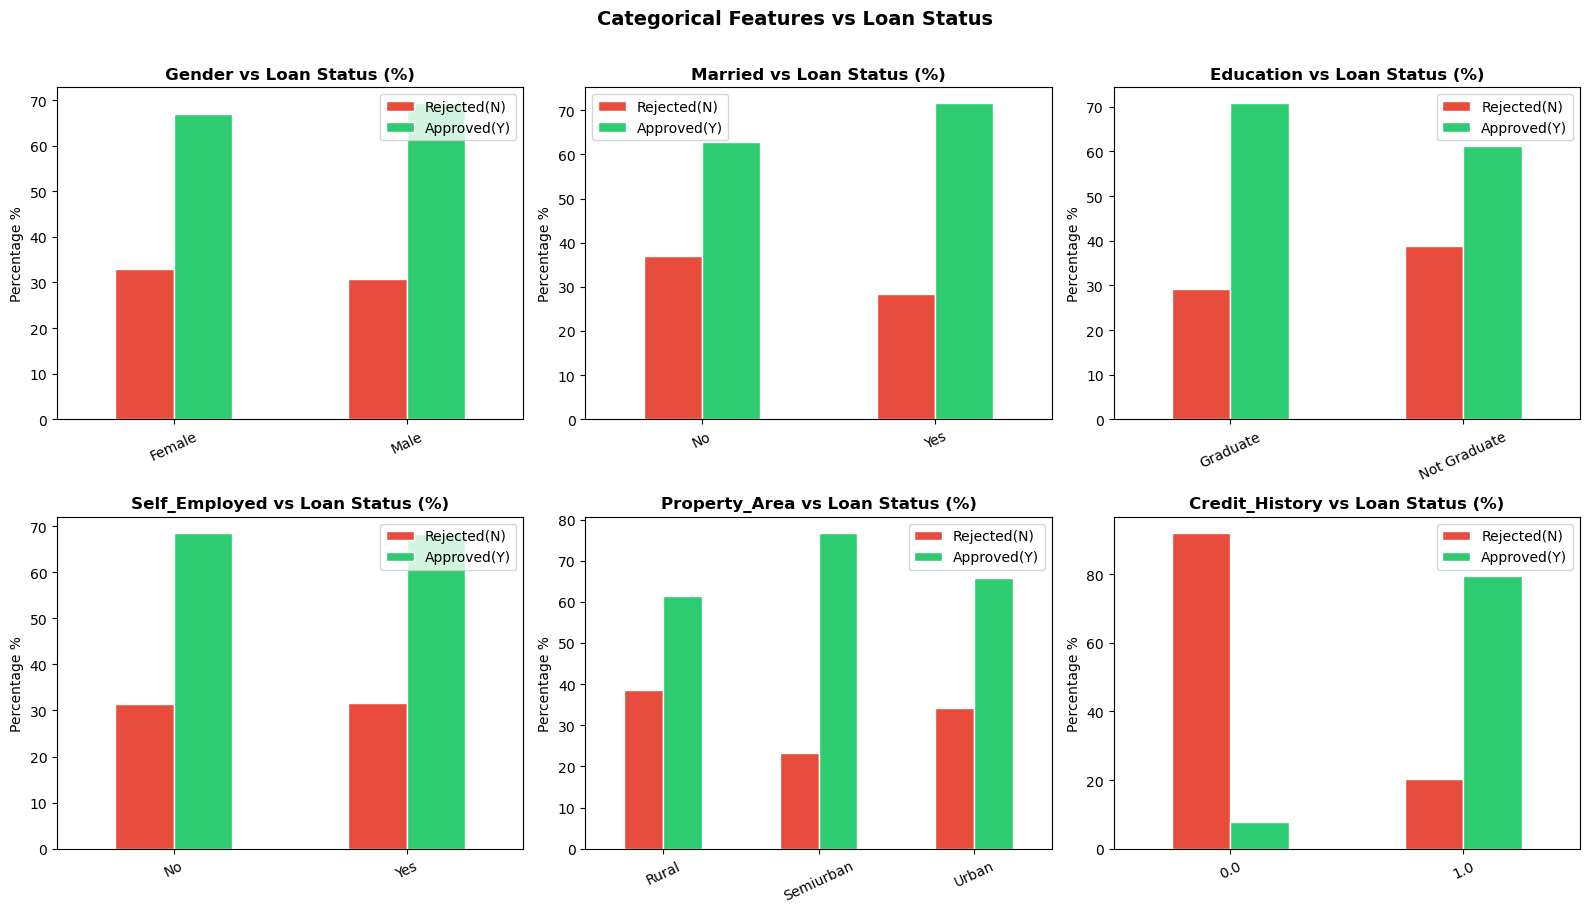

In [8]:
cat_cols = ['Gender','Married','Education','Self_Employed','Property_Area','Credit_History']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train[col], train['Loan_Status'], normalize='index') * 100
    ct.columns = ['Rejected(N)', 'Approved(Y)']
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c','#2ecc71'], edgecolor='white', rot=25)
    axes[i].set_title(f'{col} vs Loan Status (%)', fontweight='bold')
    axes[i].set_ylabel('Percentage %'); axes[i].set_xlabel('')

fig.suptitle('Categorical Features vs Loan Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/02_categoricals_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Numeric Distributions

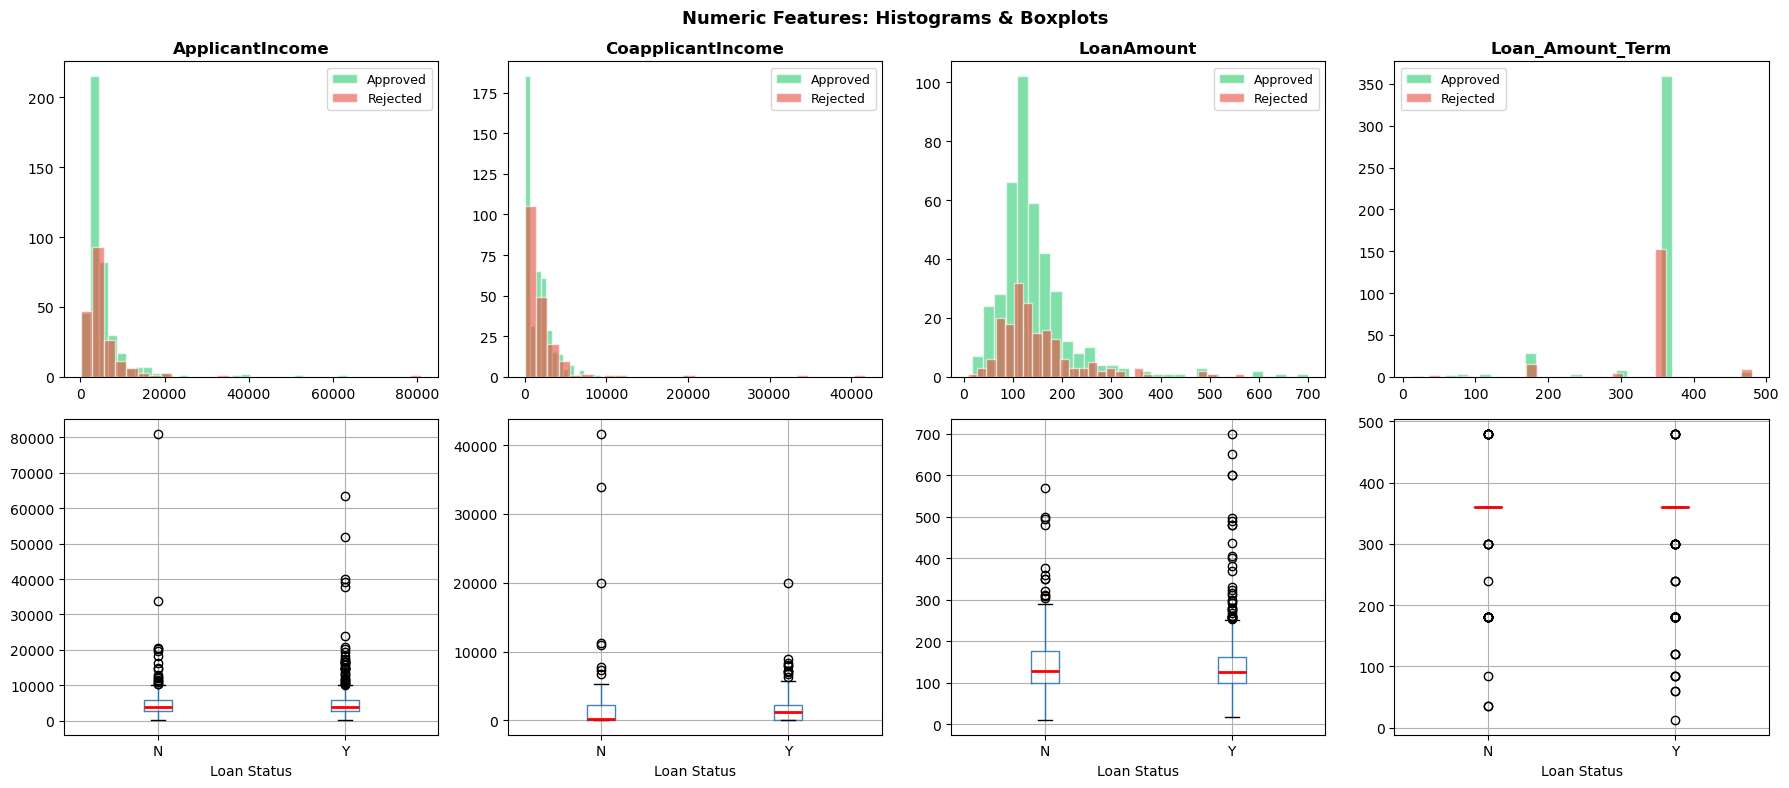

In [9]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
train_plot = train.copy()
train_plot['Loan_Status_num'] = train_plot['Loan_Status'].map({'Y':1,'N':0})

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    for status, color, label in [('Y','#2ecc71','Approved'),('N','#e74c3c','Rejected')]:
        axes[0,i].hist(train[train['Loan_Status']==status][col].dropna(),
                       bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[0,i].set_title(col, fontweight='bold'); axes[0,i].legend(fontsize=9)
    train_plot.boxplot(column=col, by='Loan_Status', ax=axes[1,i],
                       boxprops=dict(color='steelblue'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1,i].set_title(''); axes[1,i].set_xlabel('Loan Status')

fig.suptitle('Numeric Features: Histograms & Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Correlation Heatmap

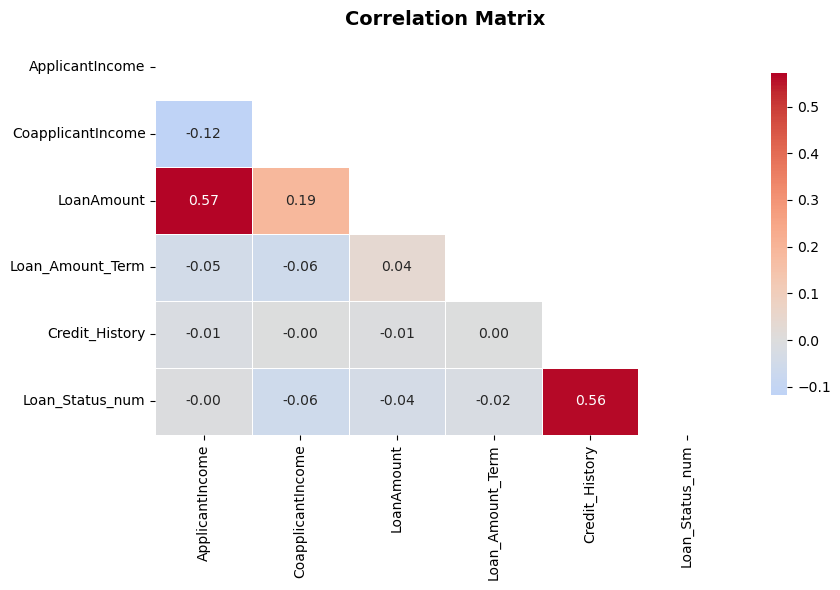

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
num_data = train_plot.drop(columns=['Loan_ID','Loan_Status'], errors='ignore').select_dtypes(include='number')
mask = np.triu(np.ones_like(num_data.corr(), dtype=bool))
sns.heatmap(num_data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Feature Engineering


In [11]:
def encode_labels(df):
    """Deterministic mapping — no statistics, safe to apply anywhere."""
    df = df.copy()
    df['Gender']        = df['Gender'].map({'Male': 1, 'Female': 0})
    df['Married']       = df['Married'].map({'Yes': 1, 'No': 0})
    df['Education']     = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
    df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
    df['Property_Area'] = df['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})
    df['Dependents']    = df['Dependents'].replace({'3+': 3}).astype(float)
    return df

def add_features(df):
    """Arithmetic features only — no cross-row statistics."""
    df = df.copy()
    df['TotalIncome']     = df['ApplicantIncome'] + df['CoapplicantIncome']
    df['Log_TotalIncome'] = np.log1p(df['TotalIncome'])          # fix skewness
    df['Log_LoanAmount']  = np.log1p(df['LoanAmount'])           # fix skewness
    df['EMI']             = df['LoanAmount'] / df['Loan_Amount_Term'].replace(0, np.nan)
    df['LoanToIncome']    = df['LoanAmount'] / (df['TotalIncome'] + 1)
    df['BalanceIncome']   = df['TotalIncome'] - df['EMI'] * 1000
    return df

train_enc = encode_labels(train.drop(columns=['Loan_ID']))
test_enc  = encode_labels(test.drop(columns=['Loan_ID']))

train_fe = add_features(train_enc)
test_fe  = add_features(test_enc)

train_fe['Loan_Status'] = train_fe['Loan_Status'].map({'Y': 1, 'N': 0})

print("New features:", ['TotalIncome','Log_TotalIncome','Log_LoanAmount','EMI','LoanToIncome','BalanceIncome'])
train_fe.head()


New features: ['TotalIncome', 'Log_TotalIncome', 'Log_LoanAmount', 'EMI', 'LoanToIncome', 'BalanceIncome']


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Log_TotalIncome,Log_LoanAmount,EMI,LoanToIncome,BalanceIncome
0,1.0,0.0,0.0,1,0.0,5849,0.0,NaN,360.0,1.0,2,1,5849.0,8.674197,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,8.714732,4.859812,0.355556,0.021011,5735.444444
2,1.0,1.0,0.0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1,3000.0,8.006701,4.204693,0.183333,0.021993,2816.666667
3,1.0,1.0,0.0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,8.505525,4.795791,0.333333,0.024282,4607.666667
4,1.0,0.0,0.0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,8.699681,4.955827,0.391667,0.023496,5608.333333


## 5 · Split First — Then Fit Preprocessor


In [12]:
FEATURE_COLS = ['Gender','Married','Dependents','Education','Self_Employed',
                'Loan_Amount_Term','Credit_History','Property_Area',
                'Log_TotalIncome','Log_LoanAmount','EMI','LoanToIncome','BalanceIncome']

X      = train_fe[FEATURE_COLS]
y      = train_fe['Loan_Status']
X_test = test_fe[FEATURE_COLS]

# ── STEP 1: Split ──────────────────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

# ── STEP 2: Fit preprocessor on TRAIN only ────────────────────────────────────
preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # median from X_train only
    ('scaler',  StandardScaler()),                    # mean/std from X_train only
])

X_train_p = preprocess.fit_transform(X_train)   # ← fit happens here
X_val_p   = preprocess.transform(X_val)          # ← transform only
X_test_p  = preprocess.transform(X_test)         # ← transform only

print("✅ Imputer & scaler fitted on training split only — zero leakage")


X_train: (491, 13)  X_val: (123, 13)  X_test: (367, 13)
✅ Imputer & scaler fitted on training split only — zero leakage


## 6 · Model Training & Comparison (5-Fold CV)

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
}

results, trained = {}, {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_p, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_p, y_train)
    trained[name] = model
    val_acc = accuracy_score(y_val, model.predict(X_val_p))
    val_roc = roc_auc_score(y_val, model.predict_proba(X_val_p)[:, 1])
    results[name] = {'CV Accuracy': cv_scores.mean(), 'CV Std': cv_scores.std(),
                     'Val Accuracy': val_acc, 'Val ROC-AUC': val_roc}
    print(f"{name:<25} CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}  "
          f"Val Acc={val_acc:.4f}  ROC-AUC={val_roc:.4f}")

results_df = pd.DataFrame(results).T.sort_values('Val ROC-AUC', ascending=False)
results_df


Logistic Regression       CV=0.7983±0.0457  Val Acc=0.8537  ROC-AUC=0.8393
Decision Tree             CV=0.7881±0.0474  Val Acc=0.8455  ROC-AUC=0.7625
Random Forest             CV=0.7800±0.0475  Val Acc=0.8374  ROC-AUC=0.8455
Gradient Boosting         CV=0.7719±0.0397  Val Acc=0.7886  ROC-AUC=0.8028
SVM                       CV=0.7942±0.0422  Val Acc=0.8537  ROC-AUC=0.8449


,CV Accuracy,CV Std,Val Accuracy,Val ROC-AUC
Random Forest,0.779963,0.047542,0.837398,0.845511
SVM,0.794249,0.042227,0.853659,0.844892
Logistic Regression,0.798268,0.045696,0.853659,0.839319
Gradient Boosting,0.771861,0.039738,0.788618,0.802786
Decision Tree,0.788126,0.047390,0.845528,0.762539


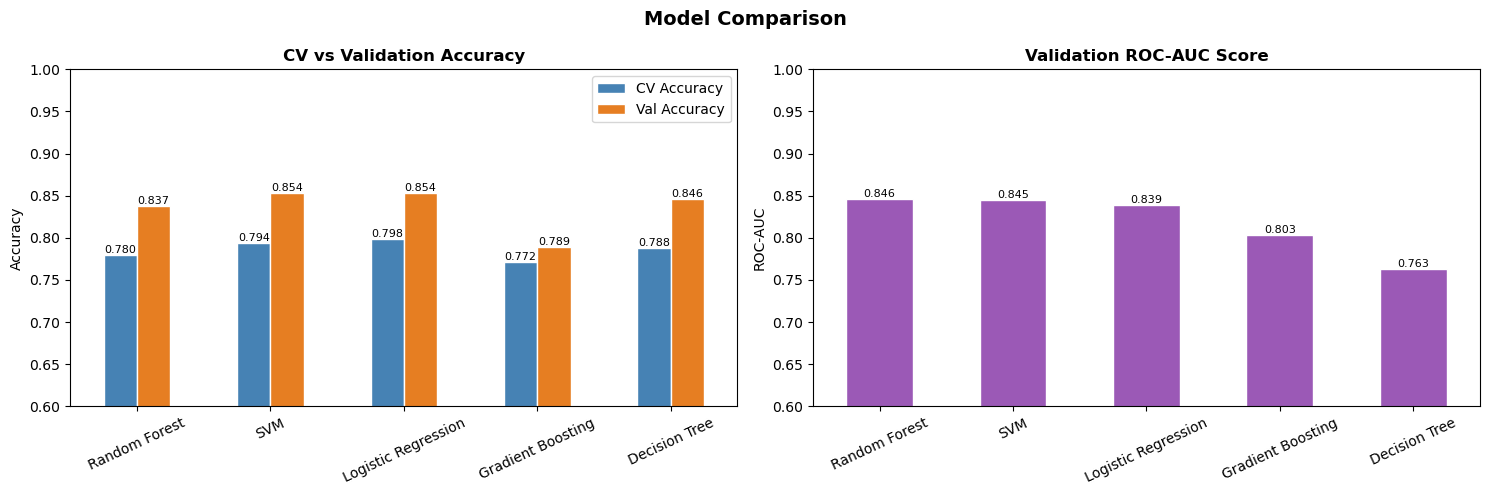

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

results_df[['CV Accuracy','Val Accuracy']].plot(
    kind='bar', ax=axes[0], color=['steelblue','#e67e22'], edgecolor='white', rot=25)
axes[0].set_title('CV vs Validation Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.6, 1.0)
for c in axes[0].containers: axes[0].bar_label(c, fmt='%.3f', fontsize=8)

results_df['Val ROC-AUC'].plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='white', rot=25)
axes[1].set_title('Validation ROC-AUC Score', fontweight='bold')
axes[1].set_ylabel('ROC-AUC'); axes[1].set_ylim(0.6, 1.0)
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.3f', fontsize=8)

fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Best Model Deep Dive

Best model: Random Forest


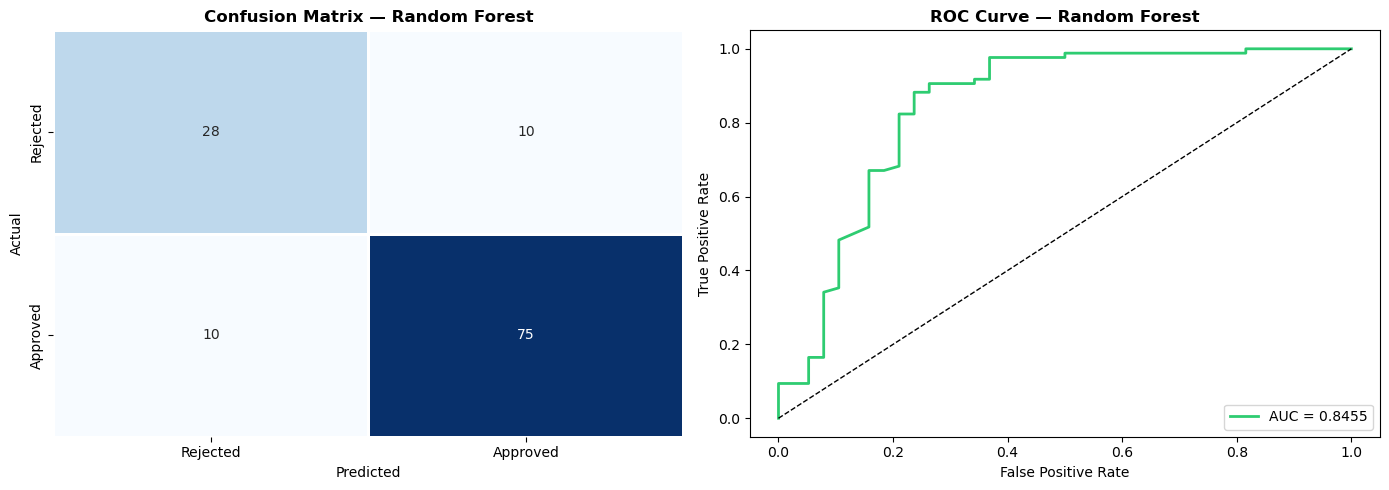

              precision    recall  f1-score   support

    Rejected       0.74      0.74      0.74        38
    Approved       0.88      0.88      0.88        85

    accuracy                           0.84       123
   macro avg       0.81      0.81      0.81       123
weighted avg       0.84      0.84      0.84       123



In [15]:
best_name  = results_df['Val ROC-AUC'].idxmax()
best_model = trained[best_name]
print(f"Best model: {best_name}")

cm    = confusion_matrix(y_val, best_model.predict(X_val_p))
probs = best_model.predict_proba(X_val_p)[:, 1]
auc   = roc_auc_score(y_val, probs)
fpr, tpr, _ = roc_curve(y_val, probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=1, cbar=False,
            xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

axes[1].plot(fpr, tpr, color='#2ecc71', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — {best_name}', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('plots/06_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_val, best_model.predict(X_val_p), target_names=['Rejected','Approved']))


### 7.1 Feature Importance (Random Forest)

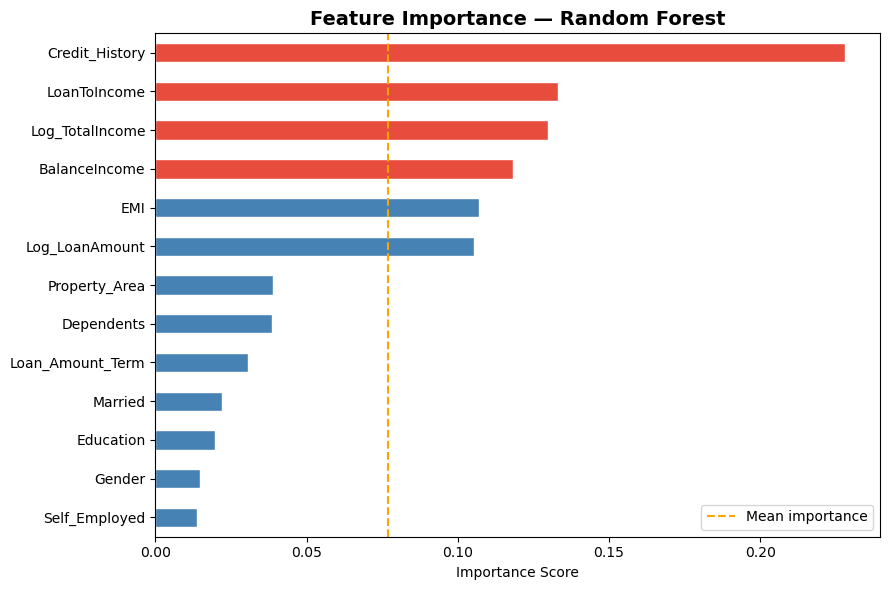

In [17]:
rf = trained['Random Forest']
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
colors = ['#e74c3c' if v >= imp.quantile(0.75) else 'steelblue' for v in imp.values]

fig, ax = plt.subplots(figsize=(9, 6))
imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(imp.mean(), color='orange', linestyle='--', lw=1.5, label='Mean importance')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score'); ax.legend()
plt.tight_layout()
plt.savefig('plots/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 8 · Predictions on Test Set

In [18]:
preds = best_model.predict(X_test_p)

submission = pd.DataFrame({
    'Loan_ID'    : test_ids,
    'Loan_Status': ['Y' if p == 1 else 'N' for p in preds],
})

print("Prediction distribution:")
print(submission['Loan_Status'].value_counts())
print(f"Approval rate: {(submission['Loan_Status']=='Y').mean()*100:.1f}%")

submission.to_csv('loan_predictions.csv', index=False)
results_df.round(4).to_csv('model_results.csv')
print("\n✅ Saved: loan_predictions.csv  |  model_results.csv")
submission.head(10)


Prediction distribution:
Loan_Status
Y    285
N     82
Name: count, dtype: int64
Approval rate: 77.7%

✅ Saved: loan_predictions.csv  |  model_results.csv


,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,N
5,LP001054,Y
6,LP001055,N
7,LP001056,N
8,LP001059,Y
9,LP001067,Y
